# Hidden Markov Models in PyMC: marginalize and recover a `DiscreteMarkovChain`

A hidden Markov model (HMM) describes a system that moves through a sequence of hidden discrete states, where each state emits a noisy observation. We never see the states directly; we only see the emissions, and we want to reason backward to the states that most likely produced them.

This notebook works through a tiny weather example: the hidden state is whether a day is rainy or sunny, the weather is "sticky" (it tends to persist from one day to the next), and our only measurement is a noisy thermometer. From the temperatures alone we will recover the most likely sequence of hidden weather states, together with our uncertainty about it.

The classic HMM inference questions are the evidence (how likely is the observed data), filtering and smoothing (the posterior over hidden states given the data), and decoding (the single most likely state path). This notebook focuses on the smoothing posterior, obtained through two composable tools from `pymc_extras`.

This example showcases three additions that together make HMM inference in PyMC turnkey:

1. **Time-varying transition matrices.** `DiscreteMarkovChain` now accepts `time_varying_P=True`, so `P` can carry one transition matrix per step with shape `(*batch, steps, k, k)`. 
2. **Marginalization of a whole chain.** `marginalize` can now integrate a `DiscreteMarkovChain` out of a model analytically (the forward algorithm), leaving only continuous parameters for NUTS to sample.
3. **Recovery of the hidden states.** `recover` (and the lower-level `conditional`) can now reconstruct the posterior over a marginalized `DiscreteMarkovChain`. The trick that makes this work is that the conditional posterior of the chain is itself a time-inhomogeneous `DiscreteMarkovChain`, which is exactly why the time-varying `P` support from point 1 is needed.

## Prepare Notebook

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from pymc_extras.distributions import DiscreteMarkovChain
from pymc_extras.marginal import conditional, marginalize, recover

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
rng = np.random.default_rng(42)

## Why hidden discrete states are hard

PyMC's default sampler is NUTS, a gradient-based method. Gradients only exist for continuous parameters, so NUTS cannot move a discrete latent variable such as our per-day weather state. Historically this left a few options: sample the discrete states with a bespoke Gibbs or Metropolis step (which mixes slowly and couples awkwardly to the continuous parameters), or hand-write the forward-backward recursions for the specific model at hand.

Marginalization offers a cleaner path. Because the hidden states are discrete and finite, we can sum them out of the likelihood exactly. NUTS then samples only the smooth, continuous parameters (here the observation noise), and we reconstruct the hidden states afterward from their exact conditional posterior. The two steps below, `marginalize` and `recover`, automate exactly this.

## The weather and the thermometer

We simulate eight days of weather. The hidden state is `0` for rain and `1` for sun, and the weather is sticky: each day it stays the same with probability `0.9`. The thermometer reads about 0 degrees Celsius on rainy days and about 20 degrees on sunny days, corrupted by Gaussian noise.

In [3]:
# Hidden weather: 0 = Rain, 1 = Sun. Weather is "sticky": it tends to persist.
P = np.array(
    [
        [0.9, 0.1],  # Rain -> [Rain, Sun]
        [0.1, 0.9],  # Sun  -> [Rain, Sun]
    ]
)

true_sunny_day = np.array([1, 1, 1, 0, 0, 0, 1, 1])  # the weather to recover
n = len(true_sunny_day)
true_sigma = 4.0
obs_temp = true_sunny_day * 20.0 + rng.normal(0, true_sigma, size=n)

days = np.arange(n)
obs_temp.round(2)

array([21.22, 15.84, 23.  ,  3.76, -7.8 , -5.21, 20.51, 18.74])

Let's plot the data.

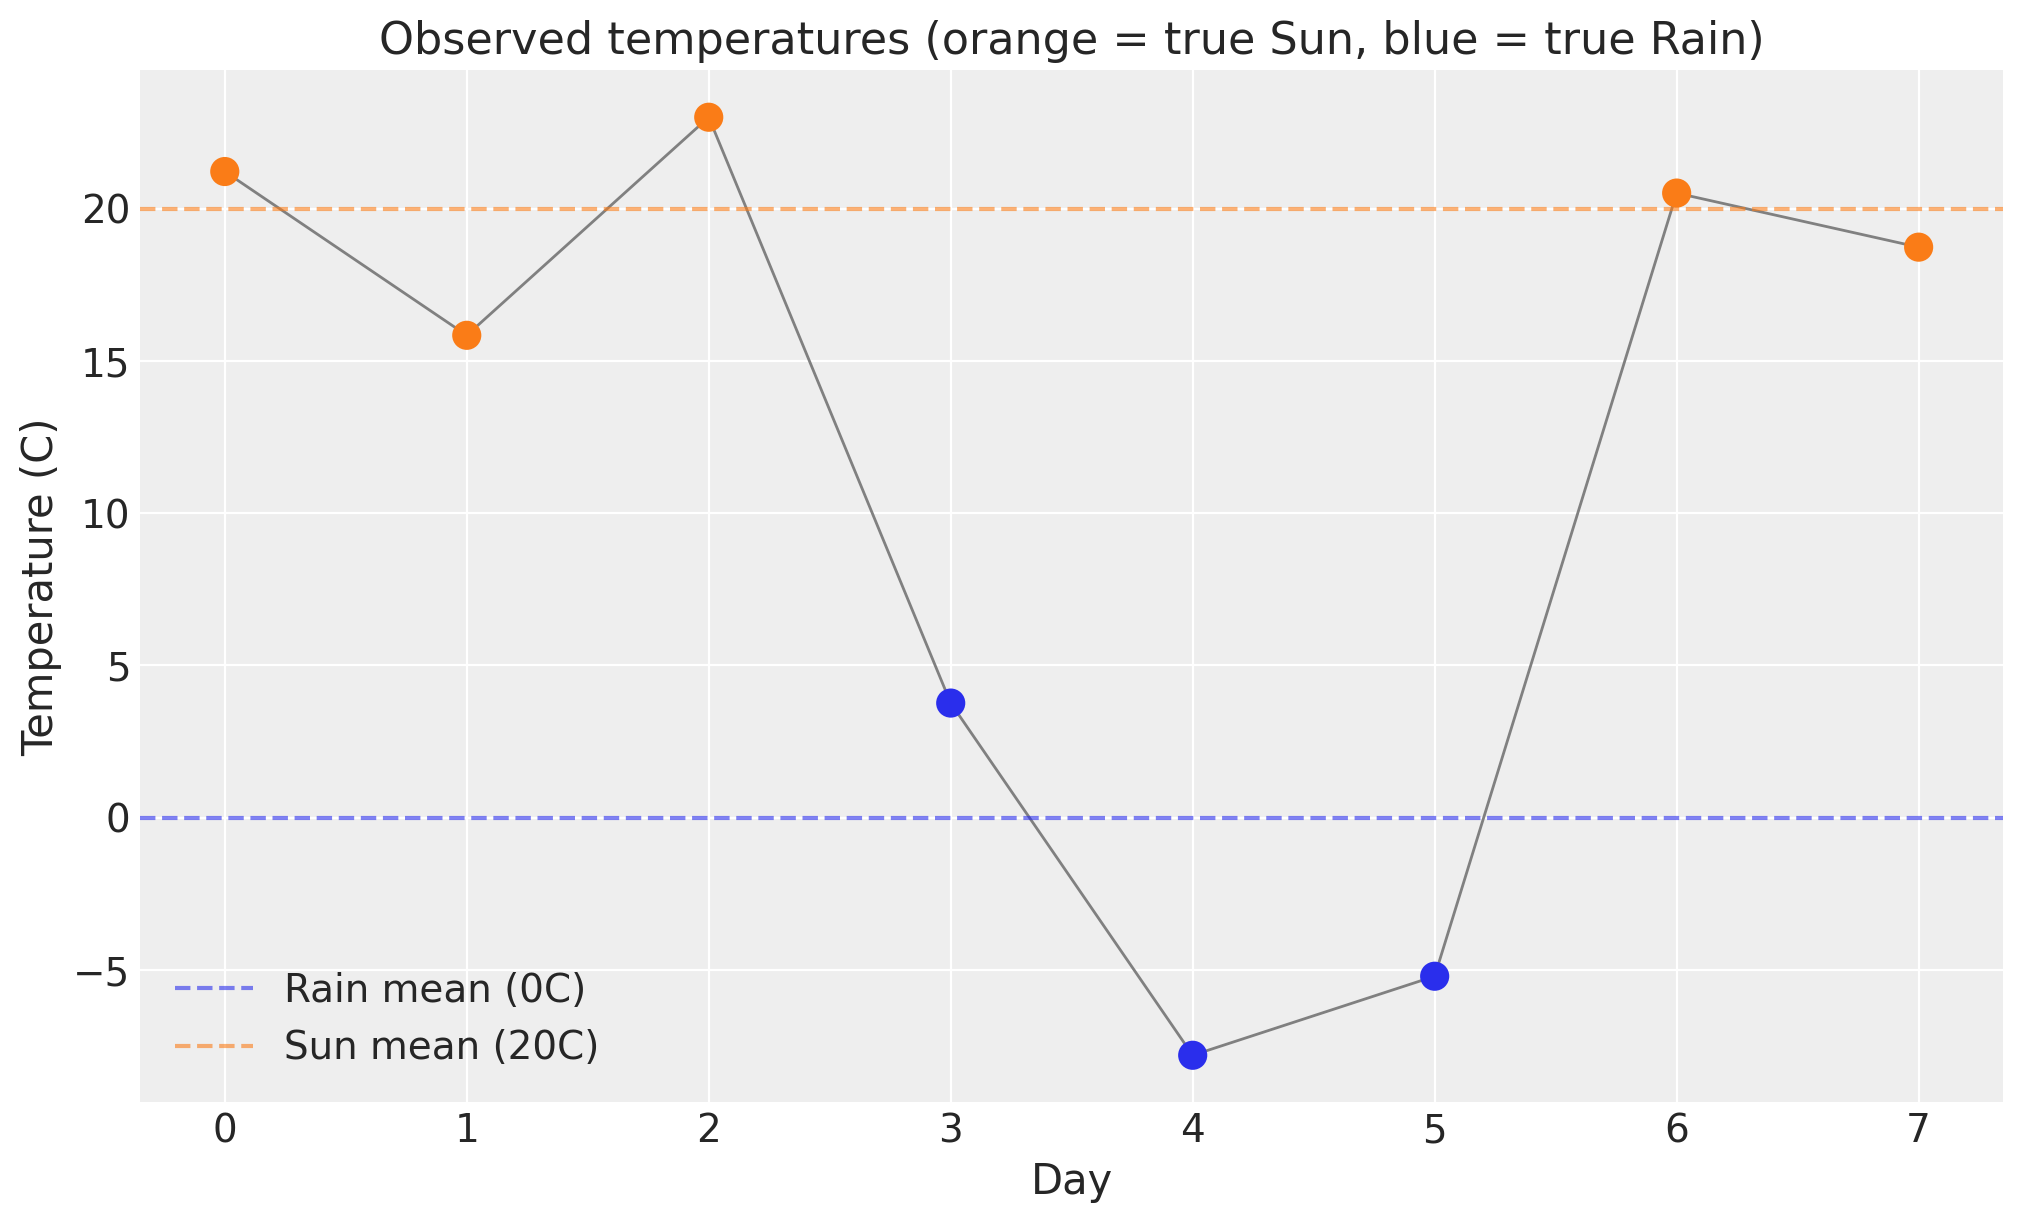

In [4]:
fig, ax = plt.subplots()
point_colors = np.where(true_sunny_day == 1, "C1", "C0")
ax.plot(days, obs_temp, color="gray", lw=1, zorder=2)
ax.scatter(days, obs_temp, c=point_colors, s=90, zorder=3)
ax.axhline(0, ls="--", color="C0", alpha=0.6, label="Rain mean (0C)")
ax.axhline(20, ls="--", color="C1", alpha=0.6, label="Sun mean (20C)")
ax.legend()
ax.set(
    xlabel="Day",
    ylabel="Temperature (C)",
    title="Observed temperatures (orange = true Sun, blue = true Rain)",
);

## The model

We place a weakly informative prior on the observation noise, a uniform prior on the first day's weather, and a `DiscreteMarkovChain` prior on the sequence of hidden states. The likelihood ties each day's temperature to its hidden state through a mean of `state * 20` degrees.

The transition matrix `P` is known and fixed here, so we can focus on the marginalize and recover mechanics. In a real application `P` would typically be given its own `Dirichlet` prior.

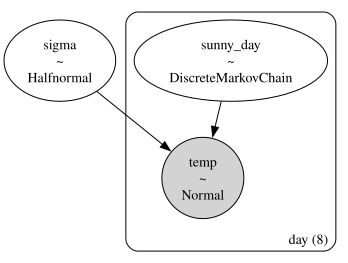

In [5]:
with pm.Model(coords={"day": days}) as model:
    sigma = pm.HalfNormal("sigma", 5.0)
    init = pm.Categorical.dist(p=[0.5, 0.5])  # day-1 prior: 50/50
    sunny_day = DiscreteMarkovChain("sunny_day", P=P, init_dist=init, dims="day")
    pm.Normal("temp", mu=sunny_day * 20.0, sigma=sigma, observed=obs_temp, dims="day")

pm.model_to_graphviz(model)

## How marginalization works

Write $x_{1:n}$ for the hidden states and $y_{1:n}$ for the temperatures. The HMM factorizes the joint distribution into an initial state, a product of transitions, and a product of emissions:

$$
p(x_{1:n}, y_{1:n} \mid \sigma) = p(x_1) \, \prod_{t=2}^{n} p(x_t \mid x_{t-1}) \, \prod_{t=1}^{n} p(y_t \mid x_t, \sigma).
$$

To sample the continuous parameter $\sigma$ with NUTS we need the marginal likelihood $p(y_{1:n} \mid \sigma)$, which sums the joint over every possible state path. Enumerating all $k^n$ paths is infeasible, but the forward algorithm computes the sum in linear time by carrying forward a vector of partial sums $\alpha_t(i) = p(y_{1:t}, x_t = i \mid \sigma)$:

$$
\alpha_1(i) = p(x_1 = i) \, p(y_1 \mid x_1 = i, \sigma), \qquad \alpha_t(j) = p(y_t \mid x_t = j, \sigma) \sum_{i} \alpha_{t-1}(i) \, p(x_t = j \mid x_{t-1} = i).
$$

The evidence is then $p(y_{1:n} \mid \sigma) = \sum_i \alpha_n(i)$.



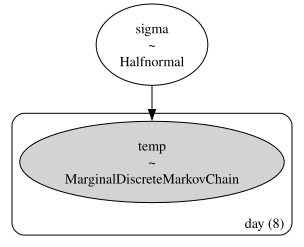

In [6]:
marginal_model = marginalize(model, ["sunny_day"])
pm.model_to_graphviz(marginal_model)

The hidden chain is gone from the graph: only the continuous `sigma` and the observed `temp` remain. This is the model NUTS actually samples.

In [7]:
idata = pm.sample(model=marginal_model, target_accept=0.85, random_seed=rng)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


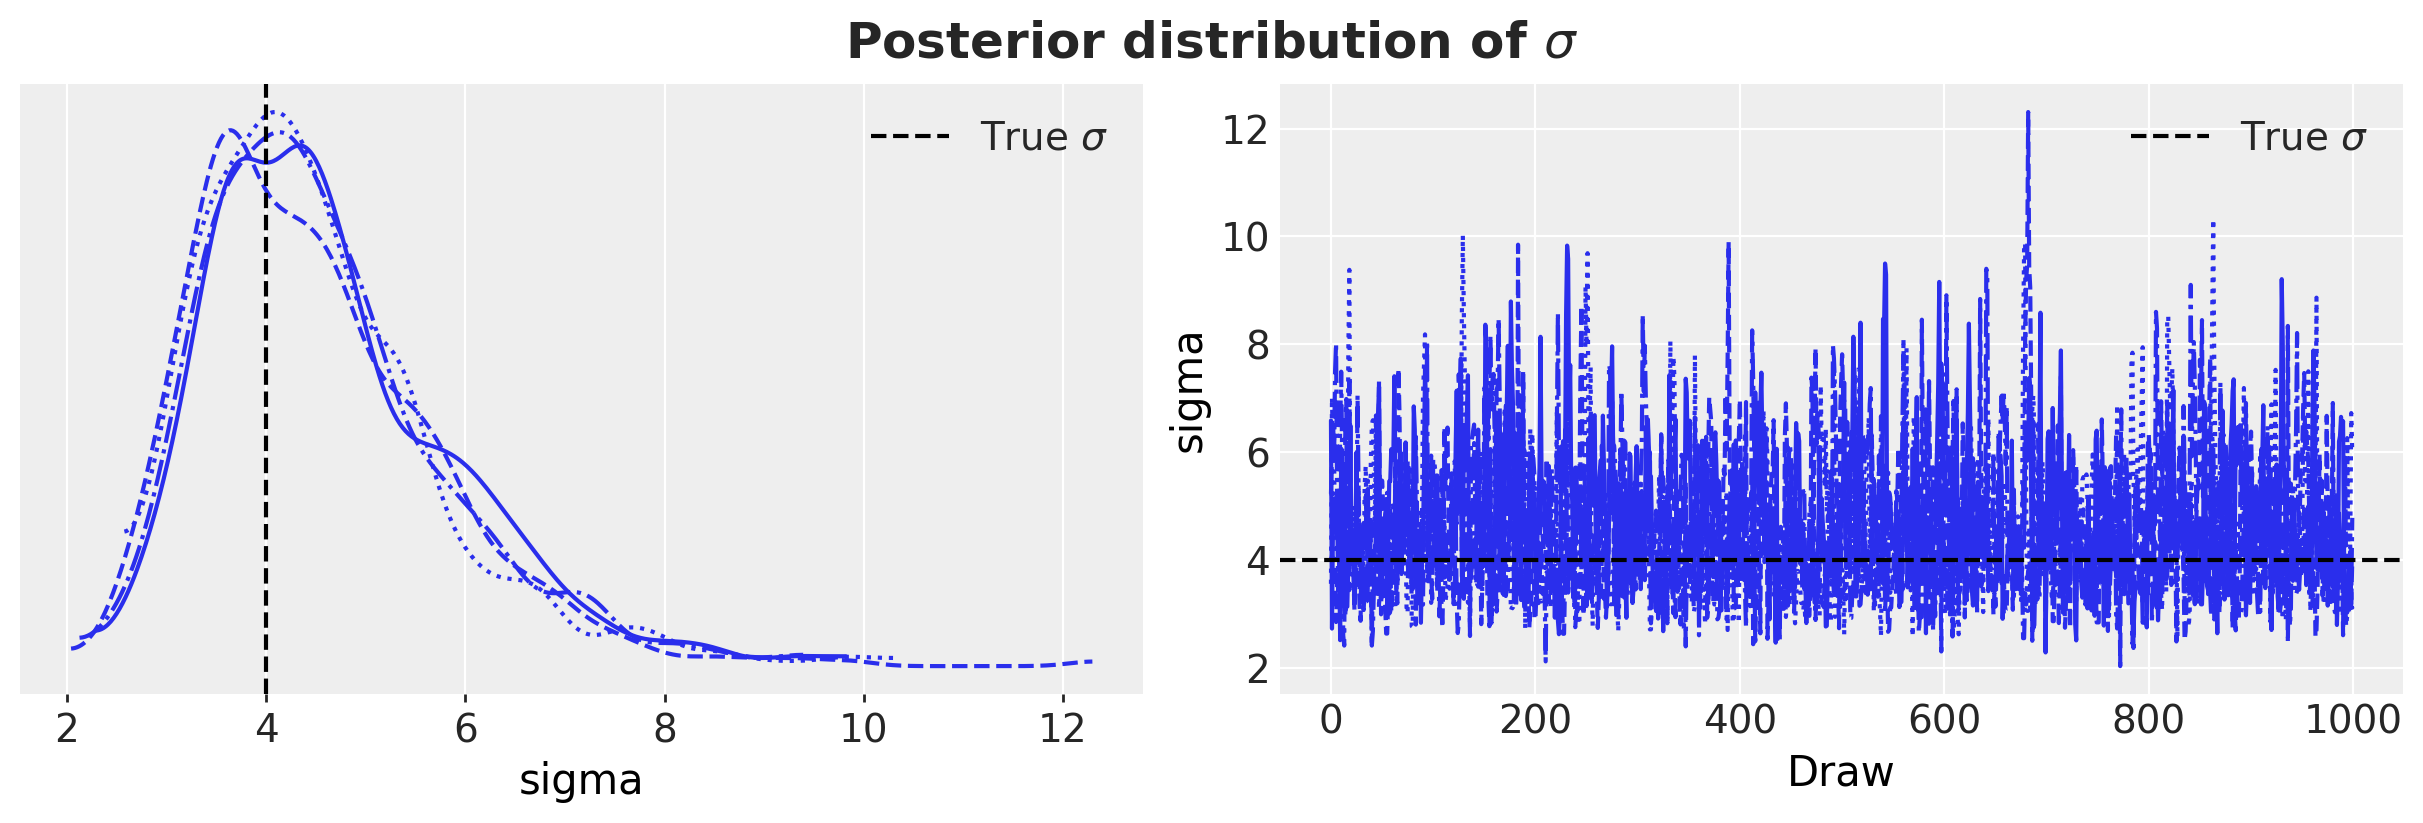

In [8]:
pc = az.plot_trace_dist(idata, var_names=["sigma"], figure_kwargs={"figsize": (12, 4)})
fig = pc.viz["figure"].values.item()
axes = fig.axes
axes[0].axvline(true_sigma, color="k", ls="--", label=r"True $\sigma$")
axes[0].legend(loc="upper right")
axes[1].axhline(true_sigma, color="k", ls="--", label=r"True $\sigma$")
axes[1].legend(loc="upper right")
fig.suptitle(r"Posterior distribution of $\sigma$", fontsize=18, fontweight="bold");

The posterior for `sigma` is smooth and well behaved because the discrete states are no longer part of the sampled space. The value used to simulate the data was `4.0`.

## How recovery works

Marginalizing removed the hidden states, but the states are usually what we actually care about. We want the smoothing posterior $p(x_t \mid y_{1:n}, \sigma)$, the probability of each hidden state given all of the data and the sampled parameters.

The forward pass above gives $\alpha_t$. A backward pass gives $\beta_t(i) = p(y_{t+1:n} \mid x_t = i, \sigma)$, and combining the two yields the per-step smoothing posterior. Crucially, the full conditional $p(x_{1:n} \mid y_{1:n}, \sigma)$ is itself a Markov chain, but one whose transition matrices change from step to step. This is why time-varying transitions matter: the recovered chain is time-inhomogeneous even when the original chain was homogeneous.


In [9]:
recover(idata, model=marginal_model, random_seed=rng)

p_sun = idata.posterior["sunny_day"].mean(("chain", "draw")).values

print("true Sun:                 ", true_sunny_day.tolist())
print("recovered P(Sun) per day: ", [float(round(p, 2)) for p in p_sun])

Sampling: [sunny_day]


true Sun:                  [1, 1, 1, 0, 0, 0, 1, 1]
recovered P(Sun) per day:  [1.0, 1.0, 1.0, 0.01, 0.0, 0.0, 1.0, 1.0]


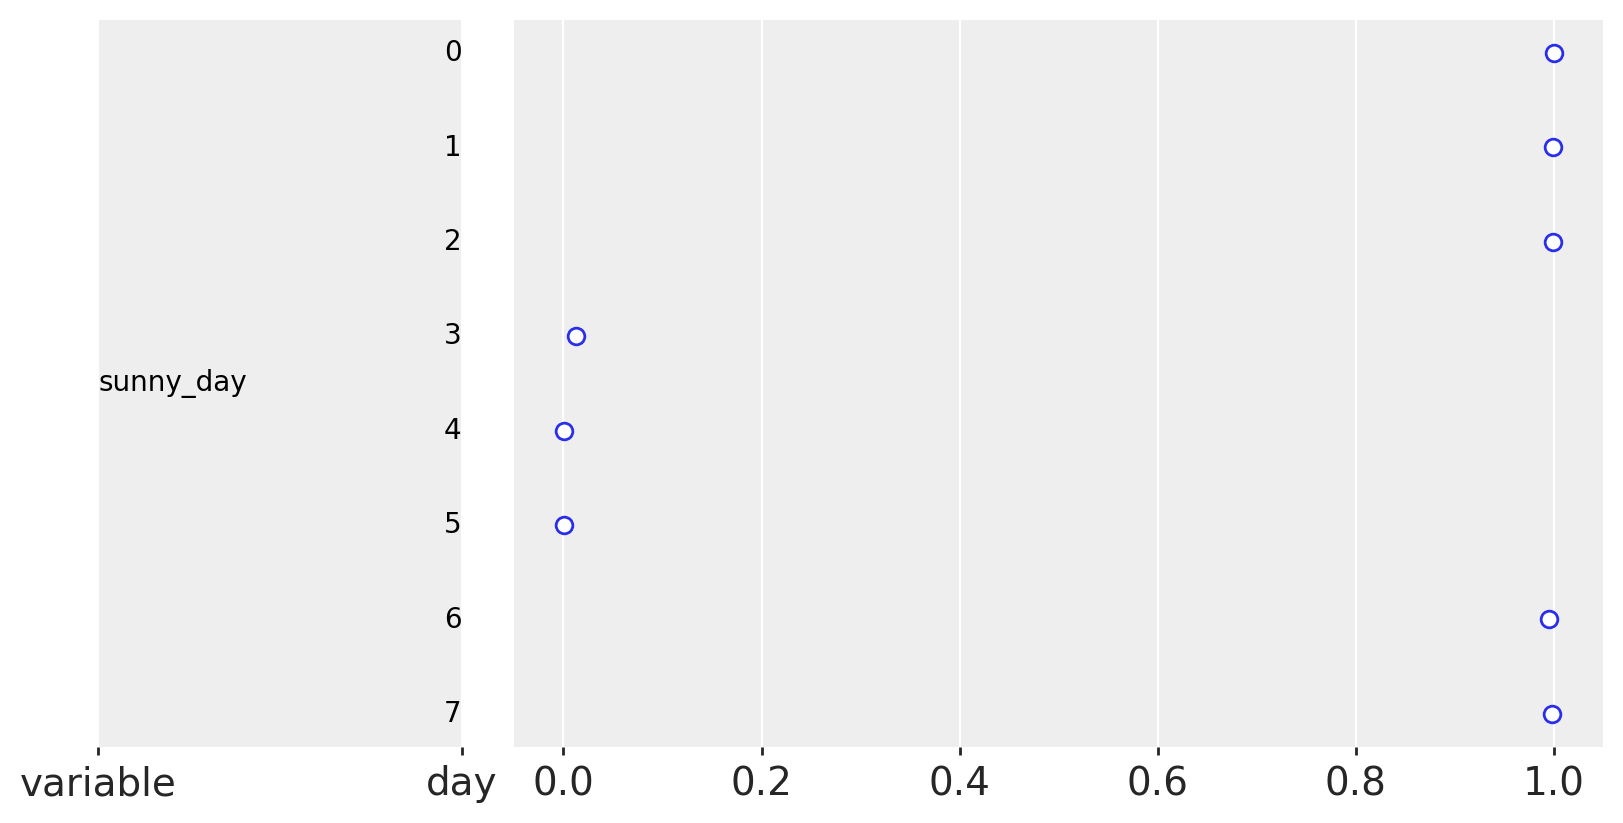

In [10]:
az.plot_forest(idata, var_names=["sunny_day"], combined=True, figure_kwargs={"figsize": (8, 4)});

We can plot the recovered probabilities of sun per day.

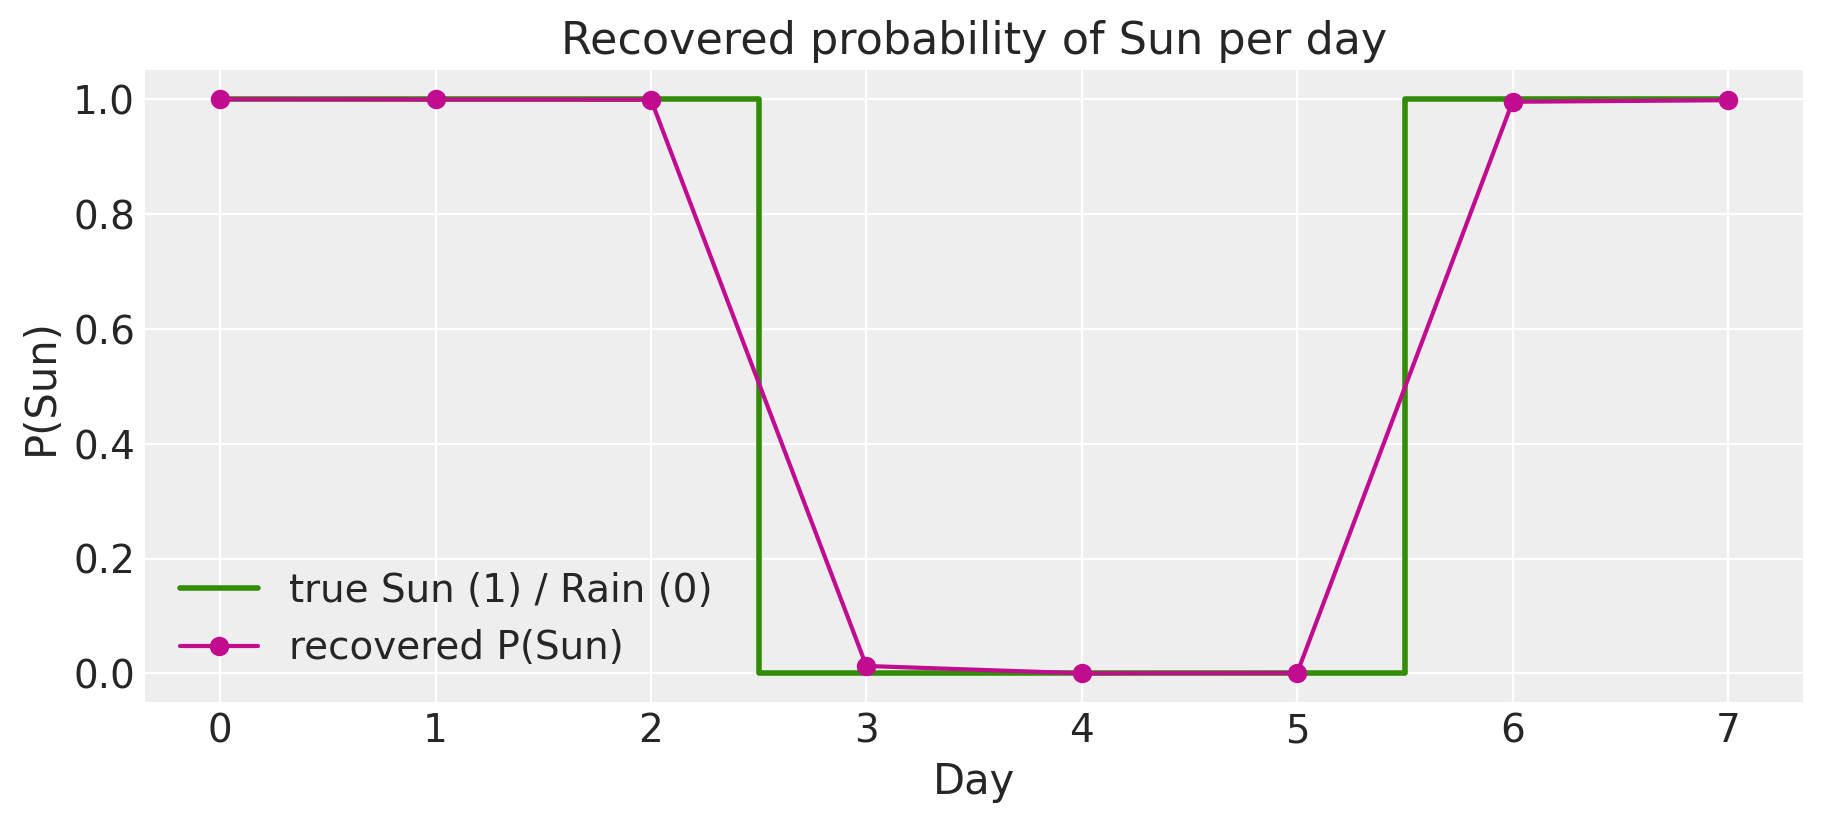

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.step(days, true_sunny_day, where="mid", color="C2", lw=2, label="true Sun (1) / Rain (0)")
ax.plot(days, p_sun, "o-", color="C3", label="recovered P(Sun)")
ax.legend()
ax.set(
    xlabel="Day",
    ylabel="P(Sun)",
    ylim=(-0.05, 1.05),
    title="Recovered probability of Sun per day",
);

The recovered probabilities snap close to the true path: the model is confident, and correct, about which days were sunny, even though it only ever saw noisy temperatures.

If you need the conditional distribution as a model object rather than posterior draws, `conditional` gives it to you directly. The recovered `sunny_day` is now a free random variable whose distribution is the conditional posterior.

In [12]:
cond_model = conditional(marginal_model)
cond_model.free_RVs

[sigma, sunny_day]

## Time-varying transitions: a change in the weather regime

So far the weather was equally sticky on every day: a single transition matrix `P` governed all of the days. Real weather is not like that. A settled high-pressure spell can hold the same conditions for a week, and then a front arrives and the weather turns unsettled, flipping between sun and rain from one day to the next.

We can capture this by letting the transition matrix change over time. The new `time_varying_P=True` flag lets `P` carry one transition matrix per step, with shape `(steps, k, k)` for a single chain (or `(*batch, steps, k, k)` with batch dimensions), where `steps` is the number of transitions, one fewer than the number of days.

We continue the weather story over a longer window. The first stretch is a stable, sticky spell; then a front arrives at `changepoint` and the weather becomes unsettled, close to a coin flip each day.

In [13]:
n_season = 14
days_season = np.arange(n_season)
changepoint = 7  # a weather front arrives, splitting the window into two regimes

# Two transition regimes for the hidden weather.
P_stable = np.array([[0.95, 0.05], [0.05, 0.95]])  # settled: weather persists
P_unsettled = np.array([[0.5, 0.5], [0.5, 0.5]])  # stormy: sun and rain flip freely

# One transition matrix per step: stable before the front, unsettled after.
P_time = np.stack([P_stable] * changepoint + [P_unsettled] * (n_season - 1 - changepoint))
P_time.shape  # (steps, k, k) with steps = n_season - 1

(13, 2, 2)

In [14]:
with pm.Model(coords={"day": days_season}) as season_prior:
    init = pm.Categorical.dist(p=[0.5, 0.5])
    DiscreteMarkovChain("sunny_day", P=P_time, init_dist=init, time_varying_P=True, dims="day")

# A prior draw of the weather: long runs during the settled spell,
# then rapid switching once the front arrives.
pm.draw(season_prior["sunny_day"], draws=1, random_seed=rng)

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0])

We now simulate a known weather sequence that spans both regimes, take noisy thermometer readings from it, and then marginalize, sample, and recover exactly as in the first example. Nothing about the workflow changes; only `P` is now time-varying.

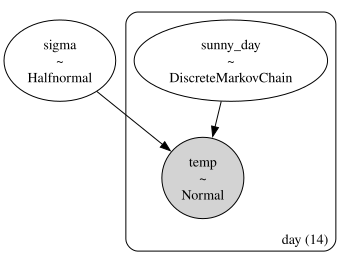

In [15]:
# A weather path that spans both regimes: long runs while settled, then alternating.
true_sunny_day_season = np.array([1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1])
obs_temp_season = true_sunny_day_season * 20.0 + rng.normal(0, true_sigma, size=n_season)

with pm.Model(coords={"day": days_season}) as season_model:
    sigma = pm.HalfNormal("sigma", 5.0)
    init = pm.Categorical.dist(p=[0.5, 0.5])
    sunny_day = DiscreteMarkovChain(
        "sunny_day", P=P_time, init_dist=init, time_varying_P=True, dims="day"
    )
    pm.Normal("temp", mu=sunny_day * 20.0, sigma=sigma, observed=obs_temp_season, dims="day")

pm.model_to_graphviz(season_model)

We now marginalize and sample.

In [16]:
season_marginal = marginalize(season_model, ["sunny_day"])
season_idata = pm.sample(model=season_marginal, target_accept=0.85, random_seed=rng)
recover(season_idata, model=season_marginal, random_seed=rng)

p_sun_season = season_idata.posterior["sunny_day"].mean(("chain", "draw")).values
print("true Sun:                 ", true_sunny_day_season.tolist())
print("recovered P(Sun) per day: ", [float(round(p, 2)) for p in p_sun_season])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.
Sampling: [sunny_day]


true Sun:                  [1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1]
recovered P(Sun) per day:  [1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0]


Let's plot the recovered probabilities of sun per day.

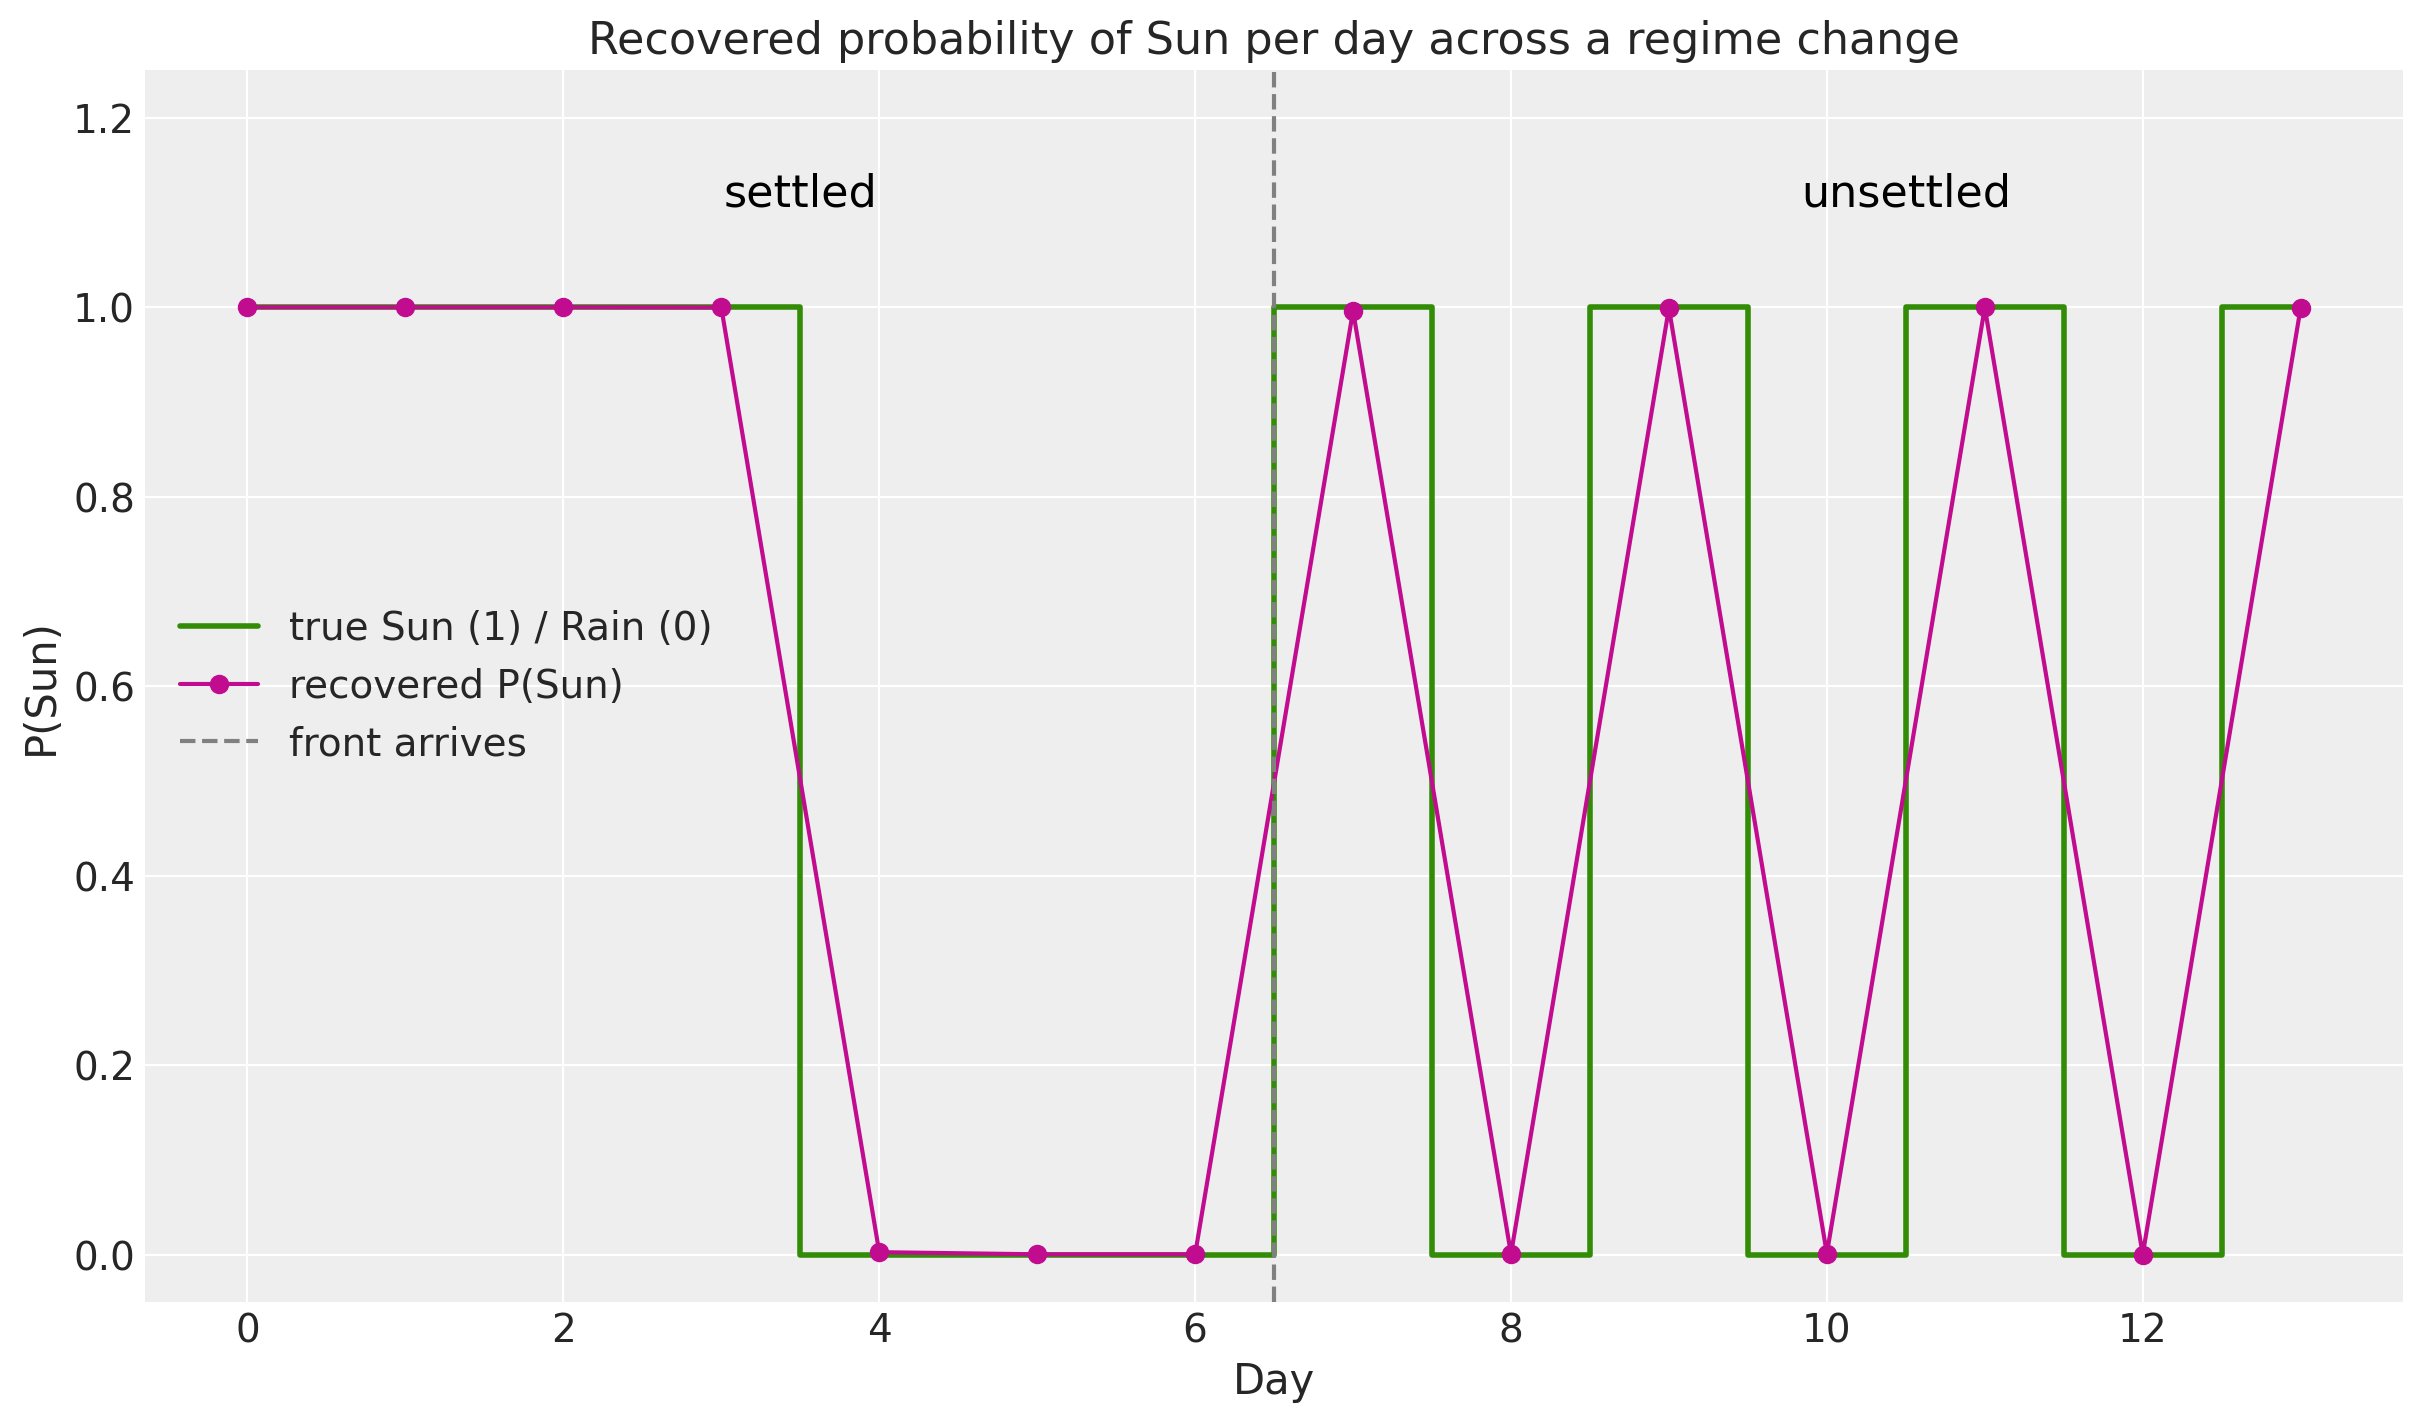

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.step(
    days_season,
    true_sunny_day_season,
    where="mid",
    color="C2",
    lw=2,
    label="true Sun (1) / Rain (0)",
)
ax.plot(days_season, p_sun_season, "o-", color="C3", label="recovered P(Sun)")
ax.axvline(changepoint - 0.5, ls="--", color="gray", label="front arrives")
ax.text(changepoint / 2, 1.12, "settled", size=16, ha="center", va="center", color="black")
ax.text(
    (changepoint + n_season) / 2,
    1.12,
    "unsettled",
    size=16,
    ha="center",
    va="center",
    color="black",
)
ax.legend(loc="center left")
ax.set(
    xlabel="Day",
    ylabel="P(Sun)",
    ylim=(-0.05, 1.25),
    title="Recovered probability of Sun per day across a regime change",
);

Recovery works identically with time-varying transitions: `recover` does not care whether `P` was shared across days or changed from day to day. The recovered probabilities stay sharp across both regimes because the thermometer strongly identifies each day on its own. In the settled spell the sticky transitions reinforce the emissions, while in the unsettled stretch the transitions carry little information, so the recovered states lean almost entirely on the temperatures.

## Summary

We inferred a hidden weather sequence from noisy temperatures using three steps:

1. Build the model with a `DiscreteMarkovChain` prior over the hidden states.
2. `marginalize` the chain so NUTS samples only the continuous parameters, using the forward algorithm under the hood.
3. `recover` the hidden states from their exact conditional posterior, which is itself a time-inhomogeneous `DiscreteMarkovChain`.
